# **Read the labeled dataset.**
golden_dataset_labeled.csv

In [64]:
import pandas as pd
golden_df = pd.read_csv("golden_dataset_labeled.csv")

In [65]:
#Split the data.
from sklearn.model_selection import train_test_split

X = golden_df["customer_tweet"]
y = golden_df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [66]:
# Convert text into vectors using TF-IDF (Baseline).
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [67]:
#Train a simple classifier.
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [68]:
pred = model.predict(X_test_vec)

In [69]:
pred

array(['Battery', 'Software Update', 'Other', 'Software Update', 'Other',
       'Software Update', 'Other', 'Other', 'Software Update',
       'Software Update', 'Other', 'Other', 'Software Update', 'Other',
       'Other', 'Other', 'Other', 'Software Update', 'Software Update',
       'Other', 'Other', 'Other', 'Software Update', 'Other',
       'Software Update', 'Software Update', 'Other', 'Other',
       'Software Update', 'Software Update', 'Other', 'Other', 'Other',
       'Other', 'Software Update', 'Other', 'Other', 'Other', 'Other',
       'Software Update'], dtype=object)

In [70]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

                 precision    recall  f1-score   support

      App Store       0.00      0.00      0.00         3
 Apple ID/Login       0.00      0.00      0.00         1
        Battery       1.00      0.33      0.50         3
   Device Issue       0.00      0.00      0.00         5
          Other       0.54      0.93      0.68        14
Payment/Billing       0.00      0.00      0.00         1
Software Update       0.53      0.67      0.59        12
         iCloud       0.00      0.00      0.00         1

       accuracy                           0.55        40
      macro avg       0.26      0.24      0.22        40
   weighted avg       0.42      0.55      0.45        40



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [71]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2
)

In [73]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(golden_df["customer_tweet"].tolist())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

# **Create embeddings**

In [74]:
X = model.encode(
    golden_df["customer_tweet"].tolist(),
    show_progress_bar=True
)

y = golden_df["intent"]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

In [75]:
#Train and Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [77]:
y_pred = clf.predict(X_test)

In [78]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.725
                 precision    recall  f1-score   support

      App Store       0.25      0.33      0.29         3
 Apple ID/Login       0.25      1.00      0.40         1
        Battery       1.00      1.00      1.00         3
   Device Issue       0.50      0.60      0.55         5
          Other       0.92      0.86      0.89        14
Payment/Billing       0.00      0.00      0.00         1
Software Update       0.90      0.75      0.82        12
         iCloud       0.00      0.00      0.00         1

       accuracy                           0.72        40
      macro avg       0.48      0.57      0.49        40
   weighted avg       0.76      0.72      0.73        40



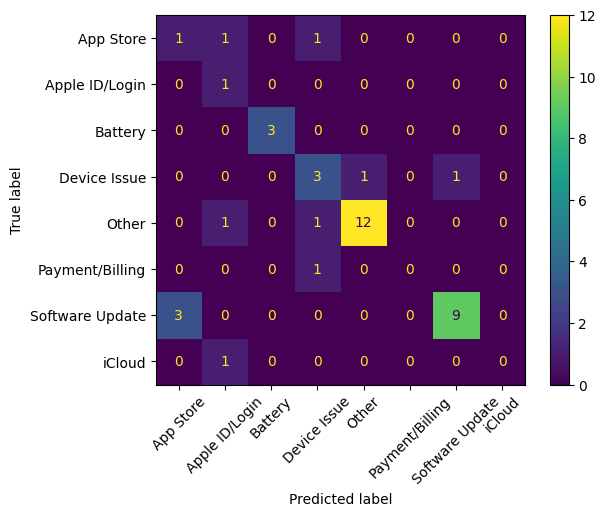

In [79]:
# confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    xticks_rotation=45
)

plt.show()

# **Build a retrieval database**

In [80]:
import pandas as pd

conversation_df = pd.read_csv("apple_conversations.csv")

conversation_df.head()

,customer_tweet,apple_reply
0,@AppleSupport https://t.co/NV0yucs0lB,@115854 We're here for you. Which version of t...
1,@AppleSupport The newest update. I️ made sure ...,@115854 Lets take a closer look into this issu...
2,@AppleSupport Tried resetting my settings .. r...,@115855 Let's go to DM for the next steps. DM ...
3,@AppleSupport This is what it looks like https...,@115855 Any steps tried since it started last ...
4,@AppleSupport I️ have an iPhone 7 Plus and yes...,@115855 That's great it has iOS 11.1 as we can...


In [81]:
# Take only 1000 conversations
conversation_sample = conversation_df.sample(
    n=1000,
    random_state=42
).reset_index(drop=True)

print(conversation_sample.shape)

(1000, 2)


In [82]:
conversation_embeddings = embedding_model.encode(
    conversation_sample["customer_tweet"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

# **Create the retrieval function**

In [83]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieve_similar(query, top_k=3):
    query_embedding = embedding_model.encode([query], convert_to_numpy=True)

    similarities = cosine_similarity(query_embedding, conversation_embeddings)[0]

    top_indices = np.argsort(similarities)[::-1][:top_k]

    return conversation_sample.iloc[top_indices]

In [84]:
retrieve_similar("My iPhone battery drains quickly")

,customer_tweet,apple_reply
231,@AppleSupport my battery is draining so fast. ...,@809266 We'd be happy to help with this. Could...
444,.@AppleSupport My battery on my iPhone 5s seem...,@454782 We are here to help. DM us your exact ...
895,@AppleSupport I'm done with ur products! Had t...,@190710 We're here for you. DM us a bit more a...


In [85]:
results = retrieve_similar("My iPhone battery drains quickly")

results[["customer_tweet", "apple_reply"]]

,customer_tweet,apple_reply
231,@AppleSupport my battery is draining so fast. ...,@809266 We'd be happy to help with this. Could...
444,.@AppleSupport My battery on my iPhone 5s seem...,@454782 We are here to help. DM us your exact ...
895,@AppleSupport I'm done with ur products! Had t...,@190710 We're here for you. DM us a bit more a...


Connect with Gemini **API**

In [86]:
!pip install -q google-generativeai

In [87]:
import google.generativeai as genai

genai.configure(api_key="AQ.Ab8RN6K0m-zbGWosAz-CBrXRAMe5XD8xO9riY2ezD2HRMgGRhQ")

model = genai.GenerativeModel("gemini-3.6-flash")

In [89]:
response = model.generate_content("Hello")
print(response.text)

TooManyRequests: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 27.159457161s.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def retrieve_similar(query, top_k=3):
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    similarities = cosine_similarity(
        query_embedding,
        conversation_embeddings
    )[0]

    top_indices = np.argsort(similarities)[::-1][:top_k]

    return conversation_sample.iloc[top_indices]

In [ ]:
results = retrieve_similar(
    "My iPhone battery drains quickly"
)

results

# **Build the AI Reply Generator**

In [ ]:
def generate_reply(customer_message):

    examples = retrieve_similar(customer_message)

    history = ""

    for _, row in examples.iterrows():
        history += f"""
Customer: {row['customer_tweet']}
Apple: {row['apple_reply']}

"""

    prompt = f"""
You are an Apple Support agent.

Use the historical Apple Support conversations below as guidance.

{history}

Now respond to this customer:

Customer:
{customer_message}

Requirements:
- Sound like Apple Support.
- Be polite and professional.
- Do not invent Apple policies.
- If more information is needed, ask for it.
"""

    response = model.generate_content(prompt)

    return response.text

In [ ]:
reply = generate_reply(
    "My iPhone battery drains very fast after updating iOS."
)

print(reply)

# **Auto vs Escalate**

In [ ]:
def decide_action(customer_message):

    text = customer_message.lower()

    escalate_keywords = [
        "refund",
        "charged",
        "legal",
        "stolen",
        "account hacked",
        "fraud",
        "payment failed"
    ]

    for word in escalate_keywords:
        if word in text:
            return "Escalate", f"Contains '{word}'"

    return "Auto", "Common support issue"

In [ ]:
print(decide_action("My Apple ID is locked"))

print(decide_action("I was charged twice"))

Instead of testing one function at a time, combine everything.

In [ ]:
def ai_support_agent(customer_message):

    # Step 1: Convert customer message into embedding
    query_embedding = embedding_model.encode(
        [customer_message],
        convert_to_numpy=True
    )

    # Step 2: Predict intent
    intent = clf.predict(query_embedding)[0]

    # Step 3: Retrieve similar AppleSupport conversations
    examples = retrieve_similar(customer_message)

    # Step 4: Build conversation history
    history = ""

    for _, row in examples.iterrows():
        history += f"""
Customer: {row['customer_tweet']}
Apple: {row['apple_reply']}

"""

    # Step 5: Create prompt for Gemini
    prompt = f"""
You are an Apple Support agent.

Predicted Intent:
{intent}

Below are historical Apple Support conversations.

{history}

New Customer Message:
{customer_message}

Write a professional Apple Support reply.

Requirements:
- Be polite and professional.
- Keep the tone similar to Apple Support.
- Do not invent Apple policies.
- If more information is needed, politely ask for it.
"""

    # Step 6: Generate reply
    response = model.generate_content(prompt)

    reply = response.text

    # Step 7: Decide Auto or Escalate
    decision, reason = decide_action(customer_message)

    # Step 8: Return results
    return {
        "Intent": intent,
        "Reply": reply,
        "Decision": decision,
        "Reason": reason
    }

In [ ]:
result = ai_support_agent(
    "My Apple ID is locked and I cannot login."
)

print(result)

In [ ]:
result = ai_support_agent("My Apple ID is locked and I cannot login.")

print("=" * 60)
print("🍎 Apple AI Support Agent")
print("=" * 60)

print(f"Customer Message:\n{'My Apple ID is locked and I cannot login.'}\n")

print(f"Predicted Intent : {result['Intent']}")
print(f"Decision         : {result['Decision']}")
print(f"Reason           : {result['Reason']}")

print("\nAI Reply")
print("-" * 60)
print(result["Reply"])

# **Evaluate the Intent Classifier**

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    xticks_rotation=45
)

plt.show()

# **Evaluate the AI Agent**

In [ ]:
test_queries = [
    "My Apple ID is locked.",
    "Battery drains quickly.",
    "I was charged twice.",
    "Photos aren't syncing.",
    "My iPhone won't turn on."
]

for query in test_queries:
    result = ai_support_agent(query)

    print("="*60)
    print("Customer:", query)
    print("Intent:", result["Intent"])
    print("Decision:", result["Decision"])
    print("Reason:", result["Reason"])
    print("Reply:", result["Reply"])

# **LLM-as-Judge**

In [ ]:
customer = "My Apple ID is locked and I cannot login."

result = ai_support_agent(customer)

reply = result["Reply"]

In [ ]:
judge_prompt = f"""
You are evaluating an AI customer support reply.

Customer:
{customer}

Reply:
{reply}

Score the reply from 1 to 5 on:

1. Helpfulness
2. Correctness
3. Tone
4. Groundedness

Return ONLY valid JSON in this format:

{{
  "Helpfulness": 5,
  "Correctness": 5,
  "Tone": 5,
  "Groundedness": 4,
  "Overall": 4.75,
  "Explanation": "Brief explanation."
}}
"""

In [ ]:
judge_response = model.generate_content(judge_prompt)

print(judge_response.text)

In [ ]:
import time

test_cases = [
    "My Apple ID is locked.",
    "Battery drains quickly.",
    "Apps won't download.",
    "I was charged twice.",
    "iCloud photos are missing."
]

for customer in test_cases:
    result = ai_support_agent(customer)
    print(result)
    print("="*80)

    time.sleep(5)